In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, classification_report

In [7]:
from google.colab import files
uploaded = files.upload()

Saving canteen.csv to canteen (1).csv


In [8]:
df = pd.read_csv("canteen.csv")

print("Canteen Dataset Shape:", df.shape)

Canteen Dataset Shape: (10, 6)


In [41]:
df = pd.read_csv("canteen.csv")
df.head()

,Day,Weather,Exam,Special_Event,Previous_Demand,Demand
0,Mon,Sunny,0,0,85,88
1,Tue,Sunny,0,0,90,94
2,Wed,Cloudy,0,0,88,91
3,Thu,Rainy,0,0,70,72
4,Fri,Sunny,1,1,105,112


In [32]:
df["Demand_Category"] = pd.cut(
    df["Demand"],
    bins=[0, 85, 105, 200],
    labels=["Low", "Medium", "High"]
)

df[["Demand", "Demand_Category"]].head()

,Demand,Demand_Category
0,88,Medium
1,94,Medium
2,91,Medium
3,72,Low
4,112,High


In [33]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Day                0
Weather            0
Exam               0
Special_Event      0
Previous_Demand    0
Demand             0
Demand_Category    0
dtype: int64


In [36]:
X = df[
    ["Day", "Weather", "Exam",
     "Special_Event", "Previous_Demand"]
]

y = df["Demand"]

print("Input Features:", X.shape)
print("Output:", y.shape)

Input Features: (10, 5)
Output: (10,)


In [37]:
print("Food Demand Distribution:")
print(df["Demand_Category"].value_counts())

Food Demand Distribution:
Demand_Category
Medium    6
Low       2
High      2
Name: count, dtype: int64


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (8, 5)
Testing Data: (2, 5)


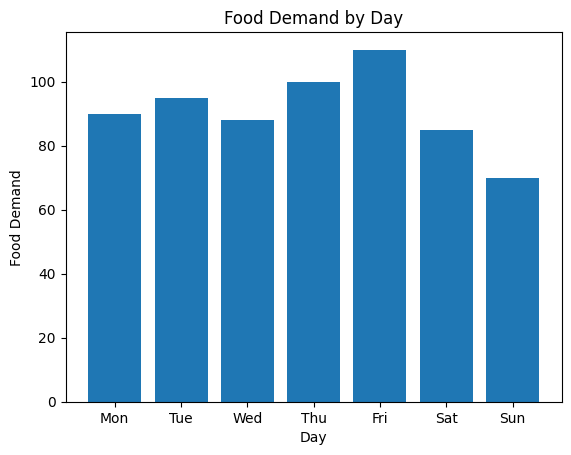

In [39]:
plt.bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"],
        [90,95,88,100,110,85,70])

plt.xlabel("Day")
plt.ylabel("Food Demand")
plt.title("Food Demand by Day")
plt.show()


In [19]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


In [20]:
y_pred = model.predict(X_test)

print("Predicted Food Demand:")
print(np.round(y_pred, 2))

Predicted Food Demand:
[80.38 92.61]


In [21]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", round(r2, 2))
print("Model Accuracy:", round(r2 * 100, 2), "%")

R2 Score: 0.83
Model Accuracy: 82.89 %


In [40]:
result = pd.DataFrame({
    "Actual Demand": y_test.values,
    "Predicted Demand": y_pred
})

result.index = range(1, len(result) + 1)

result

,Actual Demand,Predicted Demand
1,75,80.38
2,94,92.61


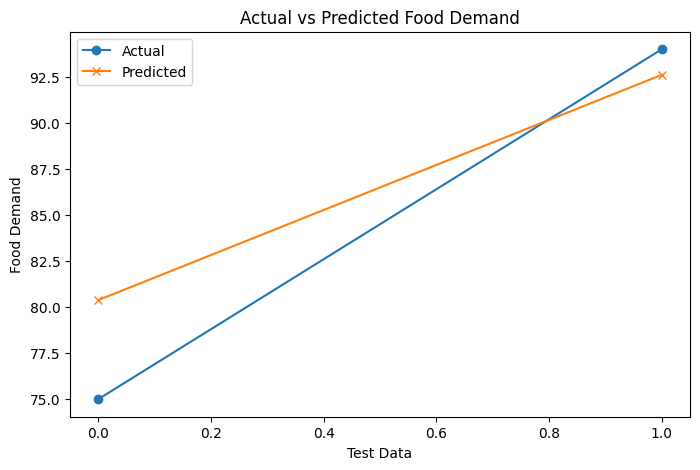

In [24]:
plt.figure(figsize=(8,5))

plt.plot(y_test.values, marker="o", label="Actual")
plt.plot(y_pred, marker="x", label="Predicted")

plt.xlabel("Test Data")
plt.ylabel("Food Demand")
plt.title("Actual vs Predicted Food Demand")
plt.legend()

plt.show()

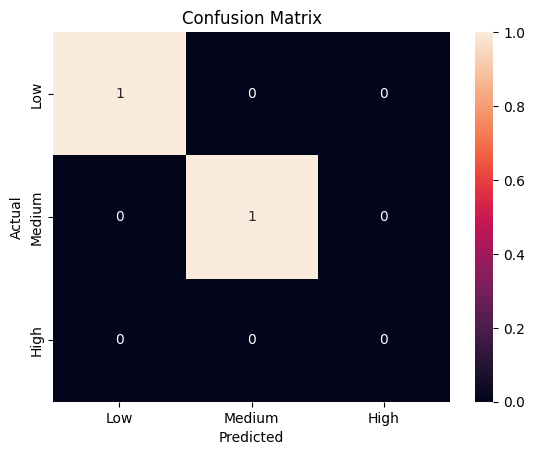

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

actual = pd.cut(y_test, [0, 85, 105, 200], labels=["Low", "Medium", "High"])
predicted = pd.cut(y_pred, [0, 85, 105, 200], labels=["Low", "Medium", "High"])

cm = confusion_matrix(actual, predicted, labels=["Low", "Medium", "High"])

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
predicted_demand = int(round(np.mean(y_pred)))
recommended_food = predicted_demand + 5
estimated_waste = recommended_food - predicted_demand

print("SMART CANTEEN FOOD DEMAND FORECAST")
print("-----------------------------------")
print("Predicted Demand:", predicted_demand)
print("Recommended Food Preparation:", recommended_food)
print("Estimated Food Waste:", estimated_waste)
print("Waste Status: MINIMIZED")

SMART CANTEEN FOOD DEMAND FORECAST
-----------------------------------
Predicted Demand: 86
Recommended Food Preparation: 91
Estimated Food Waste: 5
Waste Status: MINIMIZED
